# CNG403 Assignment 1 — Feed-Forward Neural Network from Scratch

**Objective**: Implement a complete FFNN using only raw PyTorch tensors and verify that it produces results consistent with the PyTorch `nn.Module` reference implementation.

**Workflow**:
1. [Setup](#1-setup)
2. [Data & Feature Extraction](#2-data--feature-extraction)
3. [Reference Model (nn.Module)](#3-reference-model-nnmodule)
4. [Scratch Implementation — Layers](#4-scratch-implementation--layers)
5. [Scratch Implementation — Network & Optimisers](#5-scratch-implementation--network--optimisers)
6. [Training the Scratch Model](#6-training-the-scratch-model)
7. [Comparison & Results](#7-comparison--results)
8. [Hyperparameter Tuning](#8-hyperparameter-tuning)

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')   # so we can import from src/

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.11.0+cpu
Device: cpu


In [2]:
# Load unified config
with open('config.json') as f:
    cfg = json.load(f)

print('Configuration:', json.dumps(cfg, indent=2))

Configuration: {
  "training": {
    "batch_size": 64,
    "epochs": 20,
    "learning_rate": 0.01,
    "momentum": 0.9,
    "l2_lambda": 0.0001,
    "seed": 42,
    "optimizer": "sgd"
  },
  "model": {
    "hidden_sizes": [
      256,
      128
    ],
    "activation": "relu"
  },
  "paths": {
    "checkpoint_dir": "checkpoints/",
    "log_dir": "logs/"
  }
}


## 2. Data & Feature Extraction

MNIST images are 28×28 grayscale pixels. Instead of feeding raw pixels into the network, we extract **HOG (Histogram of Oriented Gradients)** features — a classical computer vision descriptor that captures edge and texture information.

HOG parameters (from config):
- `orientations`: number of gradient orientation bins
- `pixels_per_cell`: size of each cell in pixels
- `cells_per_block`: number of cells per normalisation block

In [3]:
from data_utils import load_and_extract, set_seed

set_seed(cfg['training']['seed'])
X_train, y_train, X_val, y_val, X_test, y_test = load_and_extract('data/')

print(f'Train : {X_train.shape}  labels: {y_train.shape}')
print(f'Val   : {X_val.shape}  labels: {y_val.shape}')
print(f'Test  : {X_test.shape}  labels: {y_test.shape}')
print(f'Feature dim: {X_train.shape[1]}')

Extracting HOG features (train)…
Extracting HOG features (test)…
Train : torch.Size([54000, 144])  labels: torch.Size([54000])
Val   : torch.Size([6000, 144])  labels: torch.Size([6000])
Test  : torch.Size([10000, 144])  labels: torch.Size([10000])
Feature dim: 144


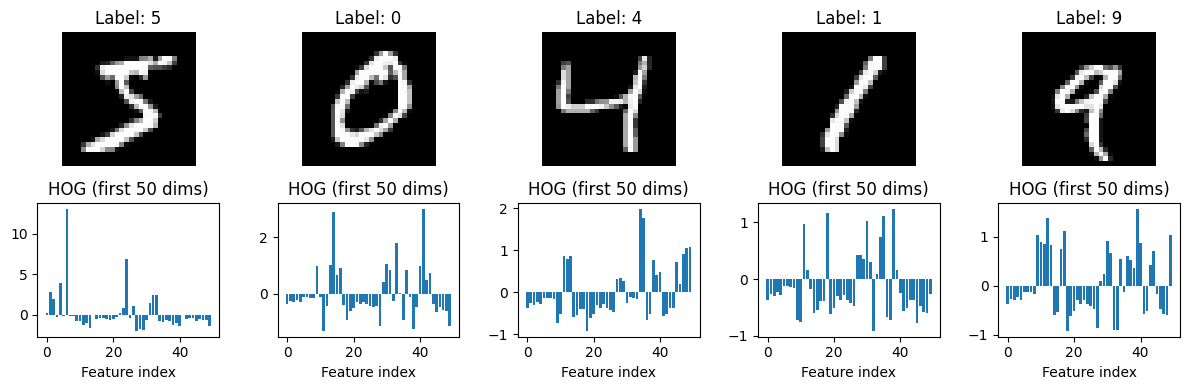

In [4]:
# Visualise a few HOG feature vectors
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
from torchvision import datasets
import torchvision.transforms as T

raw = datasets.MNIST('data/', train=True, download=True, transform=T.ToTensor())

for i, ax in enumerate(axes[0]):
    ax.imshow(raw[i][0].squeeze(), cmap='gray')
    ax.set_title(f'Label: {raw[i][1]}')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    ax.bar(range(min(50, X_train.shape[1])), X_train[i, :50].numpy())
    ax.set_title('HOG (first 50 dims)')
    ax.set_xlabel('Feature index')

plt.tight_layout()
plt.show()

## 3. Reference Model (nn.Module)

**REFERENCE ONLY:** This section runs a complete PyTorch reference implementation to establish the **target performance** your scratch implementation should match (~97% test accuracy).

*You should study this code but NOT modify it.*

In [5]:
# Run the full reference pipeline (equivalent to: python src/reference.py)
import reference
reference.run('config.json')

Device: cpu
Extracting HOG features (train)…
Extracting HOG features (test)…
Train: torch.Size([54000, 144])  Val: torch.Size([6000, 144])  Test: torch.Size([10000, 144])

Model:
Sequential(
  (0): Linear(in_features=144, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

Epoch   1/20  train_loss=0.3590  train_acc=0.8955  val_loss=0.1471  val_acc=0.9512
  Checkpoint saved → checkpoints\reference_best.pt
Epoch   2/20  train_loss=0.1445  train_acc=0.9587  val_loss=0.1196  val_acc=0.9588
  Checkpoint saved → checkpoints\reference_best.pt
Epoch   3/20  train_loss=0.1172  train_acc=0.9686  val_loss=0.1016  val_acc=0.9652
  Checkpoint saved → checkpoints\reference_best.pt
Epoch   4/20  train_loss=0.1020  train_acc=0.9731  val_loss=0.0996  val_acc=0.9662
  Checkpoint saved → checkpoints\reference_best.pt
Epoch   5/20  train_loss=0.0913  train_acc=0.9769  val_loss=0.0

In [6]:
# Load and plot reference training history
ref_history = np.load('logs/reference_history.npy', allow_pickle=True).item()
print('Keys:', list(ref_history.keys()))
print('Best val acc:', max(ref_history['val_acc']))

Keys: ['train_loss', 'train_acc', 'val_loss', 'val_acc']
Best val acc: 0.9748333333333333


## 4. Scratch Implementation — Layers

**⭐ YOUR TASK:** Open `src/layers.py` and implement each function marked with `TODO`.

Run the sanity checks below to verify your implementation matches PyTorch's reference values.

In [10]:
# Reload the module after your edits
import importlib, layers
importlib.reload(layers)
from layers import Linear, ReLU, Sigmoid, Tanh, CrossEntropyLoss

# Run the built-in sanity checks
%run src/layers.py

Sanity checks for layers.py

[Linear]
  forward  max_diff = 0.00e+00  (expect < 1e-5)
  grad_x   max_diff = 0.00e+00  (expect < 1e-5)
  grad_W   max_diff = 0.00e+00  (expect < 1e-5)
  grad_b   max_diff = 0.00e+00  (expect < 1e-5)

[ReLU]
  forward  max_diff = 0.00e+00  (expect < 1e-5)
  backward max_diff = 0.00e+00  (expect < 1e-5)

[Sigmoid]
  forward  max_diff = 1.19e-07  (expect < 1e-5)
  backward max_diff = 1.19e-07  (expect < 1e-5)

[Tanh]
  forward  max_diff = 0.00e+00  (expect < 1e-5)
  backward max_diff = 0.00e+00  (expect < 1e-5)

[CrossEntropyLoss]
  forward  max_diff = 0.00e+00  (expect < 1e-5)
  backward max_diff = 3.73e-09  (expect < 1e-5)

All checks passed (if all diffs < 1e-5).



### 4.1 Questions
Answer these in the cells below **before** moving on. Each question marks 2.

**Q1**: What is the gradient of ReLU at exactly x=0, and why does it not matter in practice?

The gradient of RELU at x=0 is undefined due to RELU being a sharp corner at x=0 and non-differentiable at that point. It doesn't matter in practice because there is a really low chance to having a probability value 0.

**Q2**: Why do we subtract the row-max before computing softmax in `CrossEntropyLoss.forward`?

We subtract the row-max to make the sigmoid/softmax function more stable. The inital formula of the function and the adjusted one are the same value mathematically, but applying the unstabilized formula will result in overflow in programming. We use the stable formula to maintain a reasonable memory usage as the space we have in the hardware is important.

**Q3**: Why is combining softmax and cross-entropy into one step numerically better than computing them separately?

I've did it separately???


## 5. Scratch Implementation — Network & Optimisers

**⭐ YOUR TASK:** Open `src/network.py` and `src/optimizers.py` and implement the functions marked with `TODO`.

Run the sanity checks below to verify your implementations work together correctly.

In [11]:
import importlib, network, optimizers
importlib.reload(network)
importlib.reload(optimizers)

%run src/network.py
%run src/optimizers.py

Sanity check for network.py

Forward  max_diff = 0.00e+00  (expect < 1e-5)
  Layer 0  dW_diff=1.49e-08  db_diff=7.45e-09  (expect < 1e-5)
  Layer 1  dW_diff=2.98e-08  db_diff=1.12e-08  (expect < 1e-5)
  Layer 2  dW_diff=2.98e-08  db_diff=7.45e-09  (expect < 1e-5)

All checks passed (if all diffs < 1e-5).

Sanity check for optimizers.py

[SGD — no momentum]
  W_diff=1.49e-08  b_diff=2.33e-10  (expect < 1e-5)
  W_diff=0.00e+00  b_diff=6.98e-10  (expect < 1e-5)

[SGD — momentum=0.9]
  W_diff=2.98e-08  b_diff=9.31e-10  (expect < 1e-5)
  W_diff=1.49e-08  b_diff=1.86e-09  (expect < 1e-5)

All checks passed (if all diffs < 1e-5).



### 5.1 Questions
Answer these in the cells below **before** moving on. Each question marks 2.

**Q4**: Explain the difference between SGD, Mini-batch GD, and Batch GD. What are the trade-offs?

The difference between them are due to their sample sizes. SGD updates the parameters sample-wise and Batch GD updates them within the number of all samples in the dataset. And Mini-batch GD stands in between them. The trade of is efficieny-reliability. When we consider SGD, since we take all of the samples one by one, calculate gradient and update value, the result will be less reliable but fast. When we consider Batch GD all of the samples impact the result at the same time so the outcome will be more reliable but slow and uses more memory. Mini-batch GD is a compromise solution of both, to achieve efficent and reliable model.

**Q5**: What does the L2 regularisation term add to the gradient? What effect does this have on the weights over time?

L2 regularisation add a hyperparameter(lambda) to the computed gradients in each layer. It's aim is to adjust the penalty that is given to the current weight. Larger lambda means we apply a heavier penalty and the gradient is coming closer to 0. Which results in a simpler model due to shrinking weights and it has the risk of underfitting. Smaller lambda means we apply weaker penalty and it results in a more flexible model with the risk of overfitting. We try to find the optimum lambda value by hyperparameter tuning and prevent both underfitting and overfitting.  

**Q6**: How does momentum help SGD? Describe intuitively what the velocity buffer represents.

The momentum help SGD in terms of repetation. If the weight moves towards a direction one on another for a time, adding the momentum will result in bigger jumps without changing the learning rate. Which results in less time consuming updates on the weights. The velocity buffer represents this consistent movement direction that the model moves towards.

## 6. Training the Scratch Model

**RUN THIS AFTER:** You've implemented all functions in sections 4 & 5.

This cell trains your FFNN using the configuration in `configs/config.json`. It saves the best model and training history for comparison.

In [12]:
# Run the full scratch training pipeline
import train
importlib.reload(train)
train.run('config.json')

Extracting HOG features (train)…
Extracting HOG features (test)…
Train: torch.Size([54000, 144])  Val: torch.Size([6000, 144])  Test: torch.Size([10000, 144])
Epoch   1/20  train_loss=0.2408  train_acc=0.9212  val_loss=0.1437  val_acc=0.9525
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   2/20  train_loss=0.1162  train_acc=0.9621  val_loss=0.1130  val_acc=0.9603
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   3/20  train_loss=0.0890  train_acc=0.9709  val_loss=0.1119  val_acc=0.9610
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   4/20  train_loss=0.0722  train_acc=0.9763  val_loss=0.1050  val_acc=0.9623
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   5/20  train_loss=0.0608  train_acc=0.9805  val_loss=0.1015  val_acc=0.9667
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   6/20  train_loss=0.0520  train_acc=0.9839  val_loss=0.0981  val_acc=0.9688
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   7/20  train_loss=0.0443  train_acc=0.9860

In [13]:
scr_history = np.load('logs/scratch_history.npy', allow_pickle=True).item()
print('Best val acc (scratch):', max(scr_history['val_acc']))

Best val acc (scratch): 0.9715


## 7. Comparison & Results

Your scratch implementation is considered **consistent** with the reference if the final test accuracy is within ~2% under the same configuration.

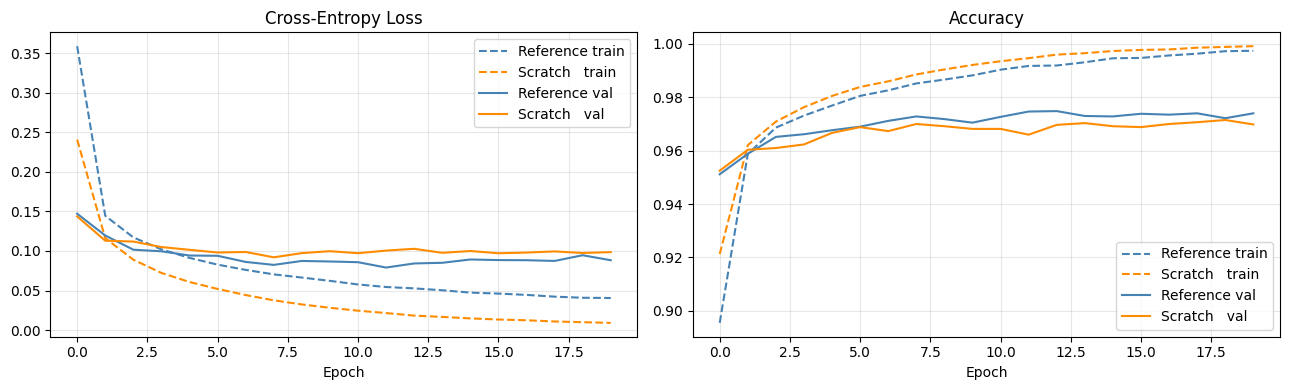

In [14]:
def plot_comparison(ref_hist, scr_hist):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, metric, title in zip(
        axes,
        ['loss', 'acc'],
        ['Cross-Entropy Loss', 'Accuracy'],
    ):
        for split, ls in [('train', '--'), ('val', '-')]:
            key = f'{split}_{metric}'
            ax.plot(ref_hist[key], ls=ls, color='steelblue',  label=f'Reference {split}')
            ax.plot(scr_hist[key], ls=ls, color='darkorange', label=f'Scratch   {split}')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('logs/comparison.png', dpi=150)
    plt.show()

plot_comparison(ref_history, scr_history)

In [ ]:
# Summary table
print(f"{'Metric':<25} {'Reference':>12} {'Scratch':>12}")
print('-' * 52)
print(f"{'Best val accuracy':<25} {max(ref_history['val_acc']):>12.4f} {max(scr_history['val_acc']):>12.4f}")
print(f"{'Final train loss':<25} {ref_history['train_loss'][-1]:>12.4f} {scr_history['train_loss'][-1]:>12.4f}")
print(f"{'Final val loss':<25} {ref_history['val_loss'][-1]:>12.4f} {scr_history['val_loss'][-1]:>12.4f}")

Metric                       Reference      Scratch
----------------------------------------------------
Best val accuracy               0.9748       0.9715
Final train loss                0.0406       0.0091
Final val loss                  0.0883       0.0986


## 8. Hyperparameter Tuning

Use the **validation set** (never the test set) to tune hyperparameters. Search over at least:
- Learning rate
- Hidden layer sizes
- Activation function
- L2 regularisation strength
- Batch size

Report your best configuration and its test accuracy **after** tuning is complete.

In [16]:
# TODO: implement your hyperparameter search here.
#
# Suggested approach: grid search or random search.
# For each candidate config, train with train.train_one_epoch + train.evaluate
# and record the best val_acc.
#
# Example skeleton:
#
# from network import FFNN
# from optimizers import SGD
# from layers import CrossEntropyLoss
# from train import train_one_epoch, evaluate
# from torch.utils.data import DataLoader, TensorDataset
#
# search_space = {
#     'lr':         [0.1, 0.01, 0.001],
#     'hidden':     [[256, 128], [512, 256], [128]],
#     'activation': ['relu', 'tanh'],
#     'l2':         [0.0, 0.0001, 0.001],
# }
#
# results = []
# for lr in search_space['lr']:
#     for hidden in search_space['hidden']:
#         ...  # train and record val_acc

search_space = {
    'lr': [0.1, 0.01, 0.001],
    'hidden': [[128], [256, 128]],
    'activation': ['relu', 'tanh'],
    'l2': [0.0, 1e-4],
    'batch_size': [32, 64]
}



results = []
for lr in search_space['lr']:
    for hidden in search_space['hidden']:
        for activation in search_space['activation']:
            for l2 in search_space['l2']:
                for batch_size in search_space['batch_size']:

                    # Build model
                    net = FFNN(input_dim, hidden, num_classes, activation)
                    loss_fn = CrossEntropyLoss()
                    optimizer = SGD(net.linear_layers, lr=lr)

                    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                    val_loader = DataLoader(val_dataset, batch_size=batch_size)

                    # Train (few epochs is enough)
                    for epoch in range(5):
                        train_one_epoch(net, train_loader, loss_fn, optimizer, l2)

                    # Evaluate
                    val_loss, val_acc = evaluate(net, val_loader, loss_fn)

                    results.append((val_acc, {
                        'lr': lr,
                        'hidden': hidden,
                        'activation': activation,
                        'l2': l2,
                        'batch_size': batch_size
                    }))

                    # Track best
                    if val_acc > best_val_acc:
                        best_val_acc = val_acc
                        best_config = results[-1][1]
                        best_net = net
#raise NotImplementedError('Implement hyperparameter search')

NameError: name 'input_dim' is not defined

In [ ]:
# TODO: report your best hyperparameters and evaluate on the TEST SET
#
# IMPORTANT: only evaluate on the test set ONCE, with your final best config.
# Evaluating multiple times on the test set is data leakage.

best_config = {
    'lr':         None,   # fill in
    'hidden':     None,   # fill in
    'activation': None,   # fill in
    'l2':         None,   # fill in
    'batch_size': None,   # fill in
}

print('Best config:', best_config)
# test_loss, test_acc = evaluate(best_net, test_loader, loss_fn)
# print(f'Test accuracy: {test_acc:.4f}')

### 8.1 Questions
Answer these in the cells below **before** finishing up. Each question marks 2.

**Q7**: Which hyperparameter had the biggest impact on validation accuracy? Why do you think that is?

[Your answer here]

**Q8**: Did you observe overfitting? How did regularisation affect it?

[Your answer here]